# PREDIÇÃO DE CONDIÇÕES METEOROLÓGICAS

# 1. Preparação da série

In [1]:
from __future__ import annotations

import gc
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import stats
from scipy.stats import shapiro, ttest_rel, wilcoxon
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from validacao_carga_inmet import carregar_e_validar_diretorio


## 1.1. CONFIGURACAO DO EXPERIMENTO

In [2]:
PASTA_DADOS = Path("./estacao_A707")
PADRAO_ARQUIVOS = "INMET*.CSV"
WMO_ESPERADO = "A707"

COLUNA_ALVO = "umidade_horaria_pct"
ROTULO_ALVO = "Umidade relativa horaria (%)"
UNIDADE_ERRO = "pontos percentuais"

ANO_INICIAL = 2011
LIMITE_AUSENCIA_ANUAL = 20.0

DATA_INICIO_VALIDACAO = pd.Timestamp("2024-01-01", tz="UTC")
DATA_INICIO_TESTE = pd.Timestamp("2025-01-01", tz="UTC")
DATA_FIM_TESTE = pd.Timestamp("2026-01-01", tz="UTC")

TAU = 24
HORIZONTES = (12, 24, 36, 48, 60, 72)
PASSO_ORIGEM_DESCRITIVO = 12
PASSO_ORIGEM_HIPOTESE = 72
SEMENTES = [10, 20, 30, 40, 50]

BATCH_TREINO = 512
BATCH_AVALIACAO = 1024
MAX_EPOCAS = 200
LR = 0.001
PACIENCIA_LINEAR = 30
PACIENCIA_GRU = 30

PASTA_SAIDAS = Path("resultados_relatorio_parcial")
PASTA_SAIDAS.mkdir(parents=True, exist_ok=True)

In [3]:
resultado_carga = carregar_e_validar_diretorio(
    pasta=PASTA_DADOS,
    padrao=PADRAO_ARQUIVOS,
    wmo_esperado=WMO_ESPERADO,

    # A validação inicial não depende de um alvo.
    coluna_alvo_criterio=None,

    # Exclui somente erros estruturais.
    excluir_arquivos_com_erro_estrutural=True,

    # Salva cópias com ",numero" corrigido.
    salvar_copias_preprocessadas=True
)

df = resultado_carga["dados"].copy()
relatorio_arquivos = resultado_carga["relatorio_arquivos"]
relatorio_colunas = resultado_carga["relatorio_colunas"]
relatorio_global = resultado_carga["relatorio_global_colunas"]
registro_preprocessamento = resultado_carga["relatorio_preprocessamento"]

In [4]:
print(relatorio_arquivos.to_string(index=False))

                                                         arquivo  wmo             estacao     latitude    longitude altitude  n_linhas  n_colunas_originais                    inicio                       fim  timestamps_invalidos  timestamps_duplicados  lacunas_horarias  n_correcoes_decimal_sem_zero  n_linhas_com_correcao_decimal                                                                colunas_vazias_no_arquivo  n_colunas_vazias_no_arquivo coluna_alvo_criterio  ausencia_alvo_pct  maior_bloco_ausente_alvo_horas colunas_desconhecidas colunas_faltantes colunas_canonicas_duplicadas  violacoes_faixa_total  erro_estrutural  aprovado_estrutural aprovado_modelagem_alvo
INMET_SE_SP_A707_PRESIDENTE PRUDENTE_01-01-2004_A_31-12-2004.CSV A707 PRESIDENTE PRUDENTE -22,11999999        -51,4   435,55      8784                   19 2004-01-01 00:00:00+00:00 2004-12-31 23:00:00+00:00                     0                      0                 0                           197                        

In [5]:
print(relatorio_global.to_string(index=False))

                                 coluna  n_arquivos  n_arquivos_com_dados  n_arquivos_vazios  n_registros_total  n_validos_total  n_ausentes_total  percentual_ausente_global  minimo_global  maximo_global  violacoes_faixa_total                                                             sugestao
          precipitacao_total_horario_mm          24                    24                  0             206640           181054             25586                  12.381920            0.0           48.0                      0                                         MANTER: possui dados válidos
             pressao_estacao_horaria_mb          24                    16                  8             206640           123682             82958                  40.146148          950.7          977.6                      0 MANTER COM RESSALVA: vazia em alguns anos; avaliar período do modelo
           pressao_max_hora_anterior_mb          24                    16                  8             206640 

In [6]:
colunas_vazias_globais = resultado_carga["colunas_vazias_globais"]
df = df.drop(columns=colunas_vazias_globais, errors="ignore")

In [7]:
if COLUNA_ALVO not in df.columns:
    raise KeyError(f"A coluna-alvo nao foi encontrada: {COLUNA_ALVO}")

if df.empty:
    raise ValueError("Nenhum arquivo estruturalmente valido foi carregado.")

In [8]:
# Trabalha somente a partir do ano escolhido para o experimento.
df = df.loc[df["datetime"].dt.year >= ANO_INICIAL].copy()
df = df.sort_values("datetime").reset_index(drop=True)
df["ano"] = df["datetime"].dt.year.astype(int)

In [9]:
def resumir_alvo_por_ano(
    dados: pd.DataFrame,
    coluna_alvo: str,
    limite_ausencia: float,
) -> pd.DataFrame:
    tabela = (
        dados.groupby("ano")[coluna_alvo]
        .agg(
            registros="size",
            validos="count",
            media="mean",
            minimo="min",
            maximo="max",
        )
        .reset_index()
    )
    tabela["ausentes"] = tabela["registros"] - tabela["validos"]
    tabela["ausencia_pct"] = 100 * tabela["ausentes"] / tabela["registros"]
    tabela["aprovado_percentual"] = tabela["ausencia_pct"] <= limite_ausencia
    tabela["classificacao"] = np.select(
        [
            tabela["ausencia_pct"] <= 10,
            tabela["ausencia_pct"] <= limite_ausencia,
        ],
        ["Aceitavel", "Revisar"],
        default="Excluir",
    )
    return tabela

In [10]:
resumo_alvo_anual = resumir_alvo_por_ano(
    df,
    COLUNA_ALVO,
    LIMITE_AUSENCIA_ANUAL,
)

In [11]:
anos_aprovados = resumo_alvo_anual.loc[
    resumo_alvo_anual["aprovado_percentual"], "ano"
].astype(int).tolist()

anos_excluidos = resumo_alvo_anual.loc[
    ~resumo_alvo_anual["aprovado_percentual"], "ano"
].astype(int).tolist()

print("\nRESUMO ANUAL DO ALVO")
print(resumo_alvo_anual.to_string(index=False))
print("\nAnos aprovados:", anos_aprovados)
print("Anos excluidos para este alvo:", anos_excluidos)


RESUMO ANUAL DO ALVO
 ano  registros  validos     media  minimo  maximo  ausentes  ausencia_pct  aprovado_percentual classificacao
2011       8760     8742 62.857470    11.0    95.0        18      0.205479                 True     Aceitavel
2012       8784     8772 63.535682    14.0    99.0        12      0.136612                 True     Aceitavel
2013       8760     8738 66.269169    17.0    97.0        22      0.251142                 True     Aceitavel
2014       8760     8760 62.984932    12.0    96.0         0      0.000000                 True     Aceitavel
2015       8760     8714 67.275878    11.0   100.0        46      0.525114                 True     Aceitavel
2016       8784     7909 61.706916    16.0   100.0       875      9.961293                 True     Aceitavel
2017       8760     8690 64.438895    12.0   100.0        70      0.799087                 True     Aceitavel
2018       8760     8085 61.665059    12.0   100.0       675      7.705479                 True   

In [12]:
resumo_alvo_anual.to_csv(
    PASTA_SAIDAS / f"qualidade_anual_{COLUNA_ALVO}.csv",
    index=False,
    encoding="utf-8-sig",
)

In [13]:
# O dado original e preservado. Somente a coluna de modelagem recebe NaN nos
# anos reprovados. Nao se aplica imputacao neste experimento.
df["ano_aprovado_alvo"] = df["ano"].isin(anos_aprovados)
df["alvo_modelagem"] = df[COLUNA_ALVO].where(df["ano_aprovado_alvo"])

In [14]:
# Garantias para validacao e teste principal.
for ano_obrigatorio in (2024, 2025):
    if ano_obrigatorio not in anos_aprovados:
        raise ValueError(
            f"O ano {ano_obrigatorio} foi reprovado para {COLUNA_ALVO}. "
            "Revise o alvo, o limite ou a divisao temporal."
        )

## 1.2. Normalização com os anos de treinamento
Considerando 
```python
Treino: dados aprovados anteriores a 2024
Validação: 2024
Teste: 2025
Avaliação adicional: 2026 parcial
```

In [15]:
mascara_observacoes_treino = (
    (df["datetime"] < DATA_INICIO_VALIDACAO)
    & df["ano_aprovado_alvo"]
    & df["alvo_modelagem"].notna()
)

In [16]:
media_treino = float(df.loc[mascara_observacoes_treino, "alvo_modelagem"].mean())
desvio_treino = float(df.loc[mascara_observacoes_treino, "alvo_modelagem"].std())

if not np.isfinite(media_treino) or not np.isfinite(desvio_treino):
    raise ValueError("Media ou desvio do treino invalido.")
if desvio_treino <= 0:
    raise ValueError("O desvio-padrao do treino deve ser positivo.")

df["alvo_normalizado"] = (
    (df["alvo_modelagem"] - media_treino) / desvio_treino
).astype(np.float32)

print(f"\nMedia do treino: {media_treino:.4f}")
print(f"Desvio-padrao do treino: {desvio_treino:.4f}")


Media do treino: 62.1130
Desvio-padrao do treino: 19.8496


## 1.3. Criação das janelas

Vamos usar as últimas 24 horas para prever a hora seguinte:

In [17]:
def criar_janelas_validas(
    valores: pd.Series | np.ndarray,
    datas: pd.Series | pd.DatetimeIndex,
    tau: int,
):
    valores = np.asarray(valores, dtype=np.float32)
    datas = pd.DatetimeIndex(datas)

    X, y, datas_alvo, indices_alvo = [], [], [], []
    descartadas_nan = 0
    descartadas_tempo = 0

    for indice_alvo in range(tau, len(valores)):
        inicio = indice_alvo - tau
        entrada = valores[inicio:indice_alvo]
        alvo = valores[indice_alvo]
        datas_janela = datas[inicio:indice_alvo + 1]

        if not np.isfinite(entrada).all() or not np.isfinite(alvo):
            descartadas_nan += 1
            continue

        diferencas = datas_janela[1:] - datas_janela[:-1]
        if not (diferencas == pd.Timedelta(hours=1)).all():
            descartadas_tempo += 1
            continue

        X.append(entrada)
        y.append(alvo)
        datas_alvo.append(datas[indice_alvo])
        indices_alvo.append(indice_alvo)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
    datas_alvo = pd.DatetimeIndex(datas_alvo)
    indices_alvo = np.asarray(indices_alvo, dtype=int)

    print("\nJanelas validas:", len(X))
    print("Descartadas por NaN:", descartadas_nan)
    print("Descartadas por descontinuidade temporal:", descartadas_tempo)

    return X, y, datas_alvo, indices_alvo

In [18]:
X, y, datas_y, indices_y = criar_janelas_validas(
    df["alvo_normalizado"],
    df["datetime"],
    TAU,
)


Janelas validas: 111373
Descartadas por NaN: 25931
Descartadas por descontinuidade temporal: 0


### 1.3.1. Separar as janelas por ano

In [19]:
mascara_train = datas_y < DATA_INICIO_VALIDACAO
mascara_val = (datas_y >= DATA_INICIO_VALIDACAO) & (datas_y < DATA_INICIO_TESTE)
mascara_test = (datas_y >= DATA_INICIO_TESTE) & (datas_y < DATA_FIM_TESTE)
mascara_2026 = datas_y >= DATA_FIM_TESTE

In [20]:
X_train, y_train = X[mascara_train], y[mascara_train]
X_val, y_val = X[mascara_val], y[mascara_val]
X_test, y_test = X[mascara_test], y[mascara_test]
X_2026, y_2026 = X[mascara_2026], y[mascara_2026]

datas_train = datas_y[mascara_train]
datas_val = datas_y[mascara_val]
datas_test = datas_y[mascara_test]
datas_2026 = datas_y[mascara_2026]

indices_train = indices_y[mascara_train]
indices_val = indices_y[mascara_val]
indices_test = indices_y[mascara_test]
indices_2026 = indices_y[mascara_2026]

In [21]:
def descrever_conjunto(nome, X_conjunto, y_conjunto, datas_conjunto):
    print(f"\n{nome}: X={X_conjunto.shape}, y={y_conjunto.shape}")
    if len(datas_conjunto):
        print(f"Periodo: {datas_conjunto[0]} a {datas_conjunto[-1]}")
    else:
        print("Periodo sem janelas validas.")

descrever_conjunto("Treino", X_train, y_train, datas_train)
descrever_conjunto("Validação", X_val, y_val, datas_val)
descrever_conjunto("Teste 2025", X_test, y_test, datas_test)
descrever_conjunto("2026 parcial", X_2026, y_2026, datas_2026)

if min(len(X_train), len(X_val), len(X_test)) == 0:
    raise ValueError("Treino, validacao e teste precisam conter janelas validas.")


Treino: X=(90183, 24), y=(90183, 1)
Periodo: 2011-01-02 00:00:00+00:00 a 2023-12-31 23:00:00+00:00

Validação: X=(8183, 24), y=(8183, 1)
Periodo: 2024-01-01 00:00:00+00:00 a 2024-12-31 23:00:00+00:00

Teste 2025: X=(8317, 24), y=(8317, 1)
Periodo: 2025-01-01 00:00:00+00:00 a 2025-12-31 23:00:00+00:00

2026 parcial: X=(4690, 24), y=(4690, 1)
Periodo: 2026-01-01 00:00:00+00:00 a 2026-08-14 05:00:00+00:00


# 3. Modelos e Treinamento

## 3.1. Carregamento das variáveis

In [22]:
class GRURegressor(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        output, _ = self.gru(x)
        return self.output(output[:, -1, :])

In [23]:
def criar_modelo_linear(tau):
    return nn.Linear(tau, 1)

def criar_modelo_gru(hidden_size=64, num_layers=2, dropout=0.2):
    return GRURegressor(hidden_size, num_layers, dropout)

## 3.2. Treinamento inicial

In [24]:
def criar_dataloader(X, y, batch_size, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=torch.cuda.is_available(),
    )
    return dataset, loader

In [25]:
train_dataset, train_loader = criar_dataloader(
    X_train, y_train, BATCH_TREINO, shuffle=True
)
val_dataset, val_loader = criar_dataloader(
    X_val, y_val, BATCH_AVALIACAO, shuffle=False
)
test_dataset, test_loader = criar_dataloader(
    X_test, y_test, BATCH_AVALIACAO, shuffle=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDispositivo de treinamento:", device)


Dispositivo de treinamento: cuda


In [26]:
def configurar_semente(semente):
    random.seed(semente)
    np.random.seed(semente)
    torch.manual_seed(semente)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semente)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [27]:
def treinar_modelo(
    modelo,
    train_loader,
    val_loader,
    device,
    epocas,
    lr,
    paciencia,
):
    modelo = modelo.to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)

    usa_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=usa_amp)

    historico = {"treino": [], "validacao": []}
    melhor_val_loss = np.inf
    melhor_estado = None
    melhor_epoca = None
    epocas_sem_melhora = 0

    for epoch in range(epocas):
        modelo.train()
        soma_treino = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, enabled=usa_amp):
                pred = modelo(X_batch)
                loss = loss_fn(pred, y_batch)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            soma_treino += loss.item() * len(X_batch)

        loss_treino = soma_treino / len(train_loader.dataset)

        modelo.eval()
        soma_validacao = 0.0
        with torch.inference_mode():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device, non_blocking=True)
                y_batch = y_batch.to(device, non_blocking=True)
                with torch.amp.autocast(device_type=device.type, enabled=usa_amp):
                    pred = modelo(X_batch)
                    loss = loss_fn(pred, y_batch)
                soma_validacao += loss.item() * len(X_batch)

        loss_validacao = soma_validacao / len(val_loader.dataset)
        historico["treino"].append(loss_treino)
        historico["validacao"].append(loss_validacao)

        if loss_validacao < melhor_val_loss:
            melhor_val_loss = loss_validacao
            melhor_epoca = epoch + 1
            melhor_estado = {
                nome: tensor.detach().cpu().clone()
                for nome, tensor in modelo.state_dict().items()
            }
            epocas_sem_melhora = 0
        else:
            epocas_sem_melhora += 1

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoca {epoch + 1:03d} | "
                f"MSE treino: {loss_treino:.6f} | "
                f"MSE validacao: {loss_validacao:.6f}"
            )

        if epocas_sem_melhora >= paciencia:
            break

    if melhor_estado is None:
        raise RuntimeError("Nenhum estado valido foi produzido no treinamento.")

    modelo.load_state_dict(melhor_estado)
    historico["melhor_epoca"] = melhor_epoca
    historico["melhor_val_loss"] = melhor_val_loss
    return modelo, historico

In [28]:
modelos_treinados = {"Linear": [], "GRU": []}
historicos = {"Linear": [], "GRU": []}

In [29]:
for semente in SEMENTES:
    print(f"\nTreinando Linear, semente {semente}")
    configurar_semente(semente)
    modelo_linear, hist_linear = treinar_modelo(
        criar_modelo_linear(TAU),
        train_loader,
        val_loader,
        device,
        MAX_EPOCAS,
        LR,
        PACIENCIA_LINEAR,
    )
    modelos_treinados["Linear"].append(modelo_linear.to("cpu"))
    historicos["Linear"].append(hist_linear)

    print(f"\nTreinando GRU, semente {semente}")
    configurar_semente(semente)
    modelo_gru, hist_gru = treinar_modelo(
        criar_modelo_gru(),
        train_loader,
        val_loader,
        device,
        MAX_EPOCAS,
        LR,
        PACIENCIA_GRU,
    )
    modelos_treinados["GRU"].append(modelo_gru.to("cpu"))
    historicos["GRU"].append(hist_gru)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Treinando Linear, semente 10
Epoca 010 | MSE treino: 0.081775 | MSE validacao: 0.074825
Epoca 020 | MSE treino: 0.054909 | MSE validacao: 0.049765
Epoca 030 | MSE treino: 0.049876 | MSE validacao: 0.045528
Epoca 040 | MSE treino: 0.048826 | MSE validacao: 0.044790
Epoca 050 | MSE treino: 0.048719 | MSE validacao: 0.044751
Epoca 060 | MSE treino: 0.048734 | MSE validacao: 0.044942
Epoca 070 | MSE treino: 0.048706 | MSE validacao: 0.044865
Epoca 080 | MSE treino: 0.048743 | MSE validacao: 0.044860

Treinando GRU, semente 10
Epoca 010 | MSE treino: 0.047381 | MSE validacao: 0.042936
Epoca 020 | MSE treino: 0.045698 | MSE validacao: 0.042172
Epoca 030 | MSE treino: 0.044826 | MSE validacao: 0.040903
Epoca 040 | MSE treino: 0.044303 | MSE validacao: 0.040219
Epoca 050 | MSE treino: 0.043803 | MSE validacao: 0.040237
Epoca 060 | MSE treino: 0.043492 | MSE validacao: 0.041078
Epoca 070 | MSE treino: 0.043268 | MSE validacao: 0.040240
Epoca 080 | MSE treino: 0.042962 | MSE validacao: 0.040278

## 3.3. Carregamento dos modelos treinados

In [29]:
from pathlib import Path
from datetime import datetime
import gc

import numpy as np
import pandas as pd
import torch


In [30]:
# Criar a pasta se ela não existir
PASTA_MODELOS = Path("modelos_salvos")

if not PASTA_MODELOS.exists():
    PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

ID_EXECUCAO = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

print("Identificação da execução:", ID_EXECUCAO)

SEMENTES = [10, 20, 30, 40, 50]


Identificação da execução: 2026-09-22_16-57-50


In [31]:
def carregar_checkpoint(
    caminho,
    dispositivo=None
):
    caminho = Path(caminho)

    if not caminho.exists():
        raise FileNotFoundError(
            f"Checkpoint não encontrado: {caminho}"
        )

    if dispositivo is None:
        dispositivo = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
    else:
        dispositivo = torch.device(dispositivo)

    # map_location="cpu" evita ocupar a GPU durante a leitura.
    print(f"Carregando checkpoint: {caminho} para {dispositivo}")
    
    checkpoint = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )
    # print(f"Checkpoint carregado: {checkpoint}")

    nome_modelo = checkpoint["nome_modelo"]
    tau_checkpoint = int(checkpoint["tau"])
    hiperparametros = checkpoint.get(
        "hiperparametros",
        {}
    )

    if nome_modelo == "Linear":
        modelo = criar_modelo_linear(
            tau=tau_checkpoint
        )

    elif nome_modelo == "GRU":
        modelo = criar_modelo_gru(
            hidden_size=hiperparametros.get(
                "hidden_size",
                64
            ),
            num_layers=hiperparametros.get(
                "num_layers",
                2
            ),
            dropout=hiperparametros.get(
                "dropout",
                0.2
            )
        )

    else:
        raise ValueError(
            f"Tipo de modelo desconhecido: {nome_modelo}"
        )

    modelo.load_state_dict(
        checkpoint["model_state_dict"]
    )

    modelo = modelo.to(dispositivo)
    modelo.eval()

    metadados = {
        chave: valor
        for chave, valor in checkpoint.items()
        if chave != "model_state_dict"
    }

    historico = checkpoint.get("historico", None)

    print(
        f"Modelo carregado: {nome_modelo} | "
        f"semente: {checkpoint['semente']} | "
        f"execução: {checkpoint['id_execucao']} | "
        f"dispositivo: {dispositivo}"
    )

    return modelo, metadados, historico


### 3.1.1. Carregando um modelo individual

In [14]:
# Carregando um modelo Linear previamente treinado

caminho_linear = (
    PASTA_MODELOS
    / "linear_semente-10_2026-09-14_15-35-55.pth"
)

modelo_linear, meta_linear, historico_linear = carregar_checkpoint(
    caminho=caminho_linear,
    dispositivo="cpu"
)

# Necessário carregar o device antes de carregar os modelos, para evitar que eles sejam carregados na GPU e ocupem memória desnecessária.
device = torch.device("cpu")


Carregando checkpoint: modelos_salvos\linear_semente-10_2026-09-14_15-35-55.pth para cpu


KeyError: 'id_execucao'

In [ ]:
# Carregando um modelo GRU previamente treinado

caminho_gru = (
    PASTA_MODELOS
    / "gru_semente-10_2026-09-14_15-20-35.pth"
)

modelo_gru, meta_gru, historico_gru = carregar_checkpoint(
    caminho=caminho_gru,
    dispositivo="cpu"
)

# Necessário carregar o device antes de carregar os modelos, para evitar que eles sejam carregados na GPU e ocupem memória desnecessária.
device = torch.device("cpu")

### 3.1.2. Carregando todos os modelos de uma vez

In [38]:
# Carregando todos os modelos treinados em uma execução específica

def carregar_modelos_da_execucao(
    pasta,
    id_execucao,
    COLUNA_ALVO,
    dispositivo="cpu"
):
    pasta = Path(pasta)

    modelos = {
        "Linear": [],
        "GRU": []
    }

    metadados = {
        "Linear": [],
        "GRU": []
    }

    historicos = {
        "Linear": [],
        "GRU": []
    }

    for nome_modelo in ["Linear", "GRU"]:
        arquivos = list(
            pasta.glob(
                f"{nome_modelo.lower()}_"
                f"{COLUNA_ALVO.lower()}_"
                f"semente-*_{id_execucao}.pth"
            )
        )

        arquivos = sorted(
            arquivos,
            key=lambda caminho: int(
                caminho.name
                .split("semente-")[1]
                .split("_")[0]
            )
        )

        if not arquivos:
            raise FileNotFoundError(
                f"Nenhum checkpoint de {nome_modelo} "
                f"encontrado para a execução {id_execucao}."
            )

        for caminho in arquivos:
            modelo, meta, historico = carregar_checkpoint(
                caminho=caminho,
                dispositivo=dispositivo
            )

            modelos[nome_modelo].append(modelo)
            metadados[nome_modelo].append(meta)
            historicos[nome_modelo].append(historico)
    return modelos, metadados, historicos


In [41]:
modelos_treinados, metadados_modelos, historicos = (
    carregar_modelos_da_execucao(
        pasta=PASTA_MODELOS,
        id_execucao="2026-09-22_14-59-35",
        COLUNA_ALVO=COLUNA_ALVO,
        dispositivo="cpu"
    )
)

# Necessário carregar o device antes de carregar os modelos, para evitar que eles sejam carregados na GPU e ocupem memória desnecessária.
device = torch.device("cpu")

print(
    "\nModelos lineares carregados:",
    len(modelos_treinados["Linear"])
)

print(
    "Modelos GRU carregados:",
    len(modelos_treinados["GRU"])
)


Carregando checkpoint: modelos_salvos\linear_umidade_horaria_pct_semente-10_2026-09-22_14-59-35.pth para cpu
Modelo carregado: Linear | semente: 10 | execução: 2026-09-22_14-59-35 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\linear_umidade_horaria_pct_semente-20_2026-09-22_14-59-35.pth para cpu
Modelo carregado: Linear | semente: 20 | execução: 2026-09-22_14-59-35 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\linear_umidade_horaria_pct_semente-30_2026-09-22_14-59-35.pth para cpu
Modelo carregado: Linear | semente: 30 | execução: 2026-09-22_14-59-35 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\linear_umidade_horaria_pct_semente-40_2026-09-22_14-59-35.pth para cpu
Modelo carregado: Linear | semente: 40 | execução: 2026-09-22_14-59-35 | dispositivo: cpu
Carregando checkpoint: modelos_salvos\linear_umidade_horaria_pct_semente-50_2026-09-22_14-59-35.pth para cpu
Modelo carregado: Linear | semente: 50 | execução: 2026-09-22_14-59-35 | dispositivo: cpu
Carre

### 3.1.3 Carregar temporariamente na GPU
Se desejar acelerar uma avaliação específica:

In [ ]:
modelo_gru, meta_gru = carregar_checkpoint(
    caminho=caminho_gru,
    dispositivo="cuda"
)

Ao terminar

In [ ]:
modelo_gru.to("cpu")
del modelo_gru
gc.collect()

torch.cuda.empty_cache()

# 4. Avaliação de uma hora a frente com média das sementes

In [30]:
real_one_step = y_test.squeeze(1) * desvio_treino + media_treino
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
previsoes_one_step = {}
resumo_one_step = []

for nome_modelo in ("Linear", "GRU"):
    previsoes_sementes = []
    for semente, modelo in zip(SEMENTES, modelos_treinados[nome_modelo]):
        modelo.eval()
        with torch.inference_mode():
            pred_norm = modelo(X_test_tensor).squeeze(1).cpu().numpy()
        pred = pred_norm * desvio_treino + media_treino
        previsoes_sementes.append(pred)
        resumo_one_step.append({
            "modelo": nome_modelo,
            "semente": semente,
            "mae": float(np.mean(np.abs(real_one_step - pred))),
            "rmse": float(np.sqrt(np.mean((real_one_step - pred) ** 2))),
        })

    matriz = np.vstack(previsoes_sementes)
    previsoes_one_step[nome_modelo] = {
        "media": matriz.mean(axis=0),
        "dp": matriz.std(axis=0, ddof=1),
    }


In [39]:
resumo_one_step_df = pd.DataFrame(resumo_one_step)
print("\nMETRICAS DE UMA HORA POR SEMENTE")
print(resumo_one_step_df.to_string(index=False))
resumo_one_step_df.to_csv(
    PASTA_SAIDAS / "metricas_one_step_por_semente.csv",
    index=False,
    encoding="utf-8-sig",
)


METRICAS DE UMA HORA POR SEMENTE
modelo  semente      mae     rmse
Linear       10 2.888626 4.388871
Linear       20 2.891551 4.393136
Linear       30 2.891682 4.392544
Linear       40 2.895925 4.393377
Linear       50 2.894988 4.391795
   GRU       10 2.648544 4.120790
   GRU       20 2.658294 4.122196
   GRU       30 2.677832 4.128395
   GRU       40 2.662714 4.125432
   GRU       50 2.663972 4.125025


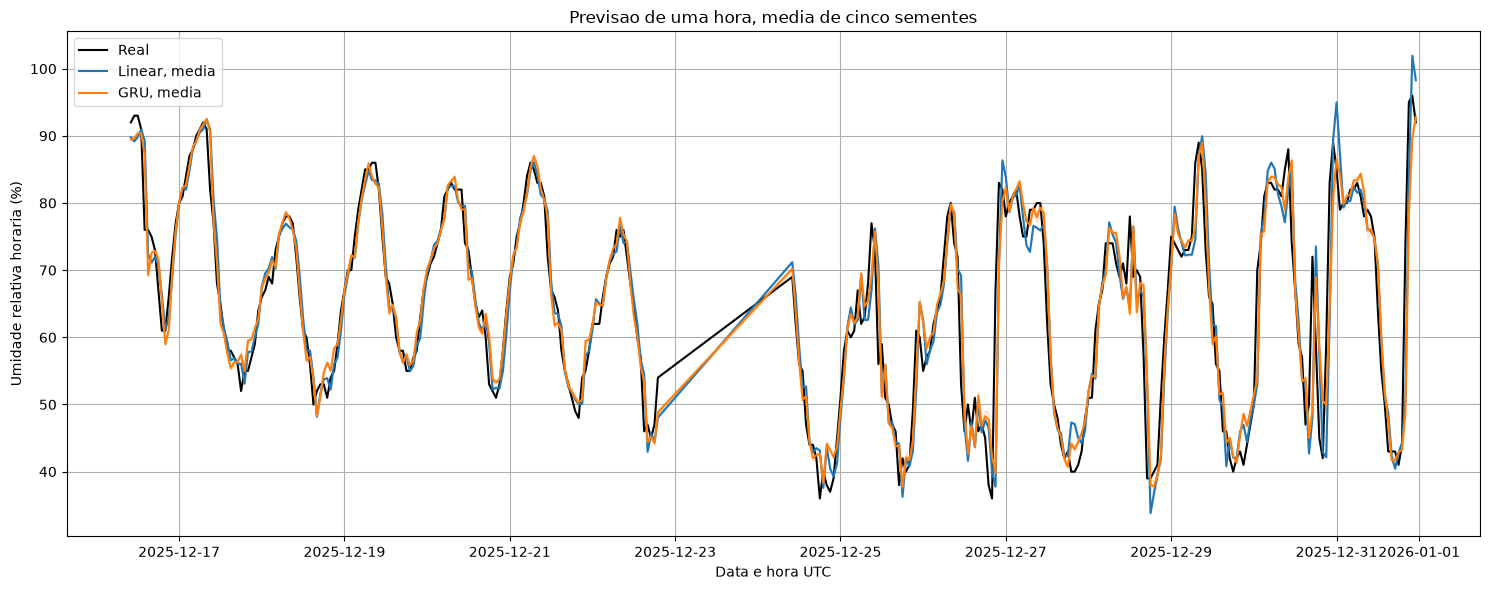

In [40]:
n_plot = min(24 * 14, len(real_one_step))
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(datas_test[-n_plot:], real_one_step[-n_plot:], color="black", label="Real")
for nome_modelo, cor in (("Linear", "tab:blue"), ("GRU", "tab:orange")):
    media = previsoes_one_step[nome_modelo]["media"][-n_plot:]
    dp = previsoes_one_step[nome_modelo]["dp"][-n_plot:]
    ax.plot(datas_test[-n_plot:], media, color=cor, label=f"{nome_modelo}, media")
    ax.fill_between(datas_test[-n_plot:], media - dp, media + dp, color=cor, alpha=0.15)
ax.set_xlabel("Data e hora UTC")
ax.set_ylabel(ROTULO_ALVO)
ax.set_title("Previsao de uma hora, media de cinco sementes")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig(PASTA_SAIDAS / "previsao_one_step_media.png", dpi=150)
plt.show()

# 5. Previsão recursiva e origens validadas

Usaremos como origem o último ponto do treinamento. O modelo não terá acesso aos valores reais do teste durante a geração.

In [41]:
serie_original = df["alvo_modelagem"].to_numpy(dtype=np.float32)
serie_normalizada = df["alvo_normalizado"].to_numpy(dtype=np.float32)
datas_serie = pd.DatetimeIndex(df["datetime"])

In [42]:
def obter_dispositivo(modelo):
    return next(modelo.parameters()).device

In [43]:
def previsao_recursiva(modelo, historico_normalizado, tau, horizonte):
    modelo.eval()
    dispositivo = obter_dispositivo(modelo)
    janela_np = np.asarray(historico_normalizado[-tau:], dtype=np.float32)
    if len(janela_np) != tau or not np.isfinite(janela_np).all():
        raise ValueError("Janela inicial invalida para previsao recursiva.")

    janela = torch.tensor(janela_np, dtype=torch.float32, device=dispositivo)
    previsoes = []
    with torch.inference_mode():
        for _ in range(horizonte):
            proximo = modelo(janela.reshape(1, tau)).squeeze()
            previsoes.append(float(proximo.item()))
            janela = torch.cat([janela[1:], proximo.reshape(1)])
    return np.asarray(previsoes, dtype=np.float32)


def previsao_sazonal(historico_original, horizonte, periodo=24):
    padrao = np.asarray(historico_original[-periodo:], dtype=np.float32)
    if len(padrao) != periodo or not np.isfinite(padrao).all():
        raise ValueError("Historico invalido para o baseline sazonal.")
    repeticoes = int(np.ceil(horizonte / periodo))
    return np.tile(padrao, repeticoes)[:horizonte]


In [44]:
def origem_temporal_valida(origem, horizonte, tau, inicio, fim):
    if origem - tau < 0 or origem + horizonte > len(df):
        return False
    if not (inicio <= datas_serie[origem] < fim):
        return False
    if datas_serie[origem + horizonte - 1] >= fim:
        return False

    intervalo = datas_serie[origem - tau:origem + horizonte]
    if len(intervalo) != tau + horizonte:
        return False
    if not ((intervalo[1:] - intervalo[:-1]) == pd.Timedelta(hours=1)).all():
        return False
    if not np.isfinite(serie_normalizada[origem - tau:origem]).all():
        return False
    if not np.isfinite(serie_original[origem:origem + horizonte]).all():
        return False
    return True


def listar_origens_validas(inicio_data, fim_data, horizonte, passo):
    candidatos = np.flatnonzero(
        (datas_serie >= inicio_data) & (datas_serie < fim_data)
    )
    if len(candidatos) == 0:
        return np.asarray([], dtype=int)
    primeiro = int(candidatos[0])
    ultimo = int(candidatos[-1])
    origens = [
        origem
        for origem in range(primeiro, ultimo + 1, passo)
        if origem_temporal_valida(origem, horizonte, TAU, inicio_data, fim_data)
    ]
    return np.asarray(origens, dtype=int)

In [46]:
def avaliar_modelo_em_origens(modelo, origens, horizontes):
    horizonte_maximo = max(horizontes)
    resultados = {
        h: {"residuos": [], "mae_por_origem": [], "rmse_por_origem": [], "origens": []}
        for h in horizontes
    }
    for origem in origens:
        pred_norm = previsao_recursiva(
            modelo,
            serie_normalizada[:origem],
            TAU,
            horizonte_maximo,
        )
        pred = pred_norm * desvio_treino + media_treino
        real = serie_original[origem:origem + horizonte_maximo]
        for h in horizontes:
            residuos = real[:h] - pred[:h]
            resultados[h]["residuos"].extend(residuos.tolist())
            resultados[h]["mae_por_origem"].append(float(np.mean(np.abs(residuos))))
            resultados[h]["rmse_por_origem"].append(float(np.sqrt(np.mean(residuos ** 2))))
            resultados[h]["origens"].append(int(origem))
    return resultados

def avaliar_baseline_em_origens(origens, horizontes, periodo=24):
    horizonte_maximo = max(horizontes)
    resultados = {
        h: {"residuos": [], "mae_por_origem": [], "rmse_por_origem": [], "origens": []}
        for h in horizontes
    }
    for origem in origens:
        pred = previsao_sazonal(serie_original[:origem], horizonte_maximo, periodo)
        real = serie_original[origem:origem + horizonte_maximo]
        for h in horizontes:
            residuos = real[:h] - pred[:h]
            resultados[h]["residuos"].extend(residuos.tolist())
            resultados[h]["mae_por_origem"].append(float(np.mean(np.abs(residuos))))
            resultados[h]["rmse_por_origem"].append(float(np.sqrt(np.mean(residuos ** 2))))
            resultados[h]["origens"].append(int(origem))
    return resultados

In [47]:
def resumir_resultados(resultados):
    linhas = []
    for horizonte, dados in resultados.items():
        residuos = np.asarray(dados["residuos"], dtype=float)
        if len(residuos) == 0:
            mae = rmse = mediana = np.nan
        else:
            mae = float(np.mean(np.abs(residuos)))
            rmse = float(np.sqrt(np.mean(residuos ** 2)))
            mediana = float(np.median(np.abs(residuos)))
        linhas.append({
            "horizonte": horizonte,
            "mae": mae,
            "rmse": rmse,
            "mediana_absoluta": mediana,
            "n_origens": len(dados["mae_por_origem"]),
            "n_previsoes": len(residuos),
        })
    return pd.DataFrame(linhas)

In [48]:
origens_teste = listar_origens_validas(
    DATA_INICIO_TESTE,
    DATA_FIM_TESTE,
    max(HORIZONTES),
    PASSO_ORIGEM_DESCRITIVO,
)

if len(origens_teste) == 0:
    raise ValueError("Nenhuma origem valida foi encontrada no teste de 2025.")

print("\nOrigens descritivas validas em 2025:", len(origens_teste))


Origens descritivas validas em 2025: 612


In [49]:
resultados_baseline_teste = avaliar_baseline_em_origens(origens_teste, HORIZONTES)
resultados_modelos_teste = {"Linear": [], "GRU": []}
registros_metricas = []

resumo_baseline = resumir_resultados(resultados_baseline_teste)
resumo_baseline["modelo"] = "Baseline sazonal"
resumo_baseline["semente"] = "baseline"
registros_metricas.append(resumo_baseline)

In [50]:
for nome_modelo in ("Linear", "GRU"):
    for semente, modelo in zip(SEMENTES, modelos_treinados[nome_modelo]):
        resultado = avaliar_modelo_em_origens(modelo, origens_teste, HORIZONTES)
        resultados_modelos_teste[nome_modelo].append(resultado)
        resumo = resumir_resultados(resultado)
        resumo["modelo"] = nome_modelo
        resumo["semente"] = semente
        registros_metricas.append(resumo)

In [51]:
metricas_por_semente = pd.concat(registros_metricas, ignore_index=True)
metricas_por_semente.to_csv(
    PASTA_SAIDAS / "metricas_multiplas_origens_por_semente.csv",
    index=False,
    encoding="utf-8-sig",
)

In [52]:
# Baseline aparece sem DP entre sementes. Linear e GRU recebem media e DP.
resumo_modelos = (
    metricas_por_semente.loc[metricas_por_semente["modelo"] != "Baseline sazonal"]
    .groupby(["modelo", "horizonte"])
    .agg(
        mae_media=("mae", "mean"),
        mae_dp=("mae", "std"),
        rmse_media=("rmse", "mean"),
        rmse_dp=("rmse", "std"),
        execucoes=("semente", "nunique"),
        n_origens=("n_origens", "first"),
    )
    .reset_index()
)

resumo_baseline_final = resumo_baseline.rename(columns={
    "mae": "mae_media",
    "rmse": "rmse_media",
})[["modelo", "horizonte", "mae_media", "rmse_media", "n_origens"]]
resumo_baseline_final["mae_dp"] = np.nan
resumo_baseline_final["rmse_dp"] = np.nan
resumo_baseline_final["execucoes"] = 1

In [53]:
resumo_final = pd.concat(
    [
        resumo_baseline_final,
        resumo_modelos[
            ["modelo", "horizonte", "mae_media", "rmse_media", "n_origens", "mae_dp", "rmse_dp", "execucoes"]
        ],
    ],
    ignore_index=True,
)
resumo_final = resumo_final.sort_values(["horizonte", "modelo"]).reset_index(drop=True)


In [54]:
print("\nRESUMO FINAL EM MULTIPLAS ORIGENS")
print(resumo_final.to_string(index=False))
resumo_final.to_csv(
    PASTA_SAIDAS / "resumo_final_multiplas_origens.csv",
    index=False,
    encoding="utf-8-sig",
)


RESUMO FINAL EM MULTIPLAS ORIGENS
          modelo  horizonte  mae_media  rmse_media  n_origens   mae_dp  rmse_dp  execucoes
Baseline sazonal         12  10.918164   15.328373        612      NaN      NaN          1
             GRU         12   7.158044   10.590200        612 0.080464 0.051451          5
          Linear         12   8.403329   11.491230        612 0.031069 0.053446          5
Baseline sazonal         24  10.955202   15.388315        612      NaN      NaN          1
             GRU         24   8.716088   12.560829        612 0.067605 0.190794          5
          Linear         24   9.567497   13.003251        612 0.025893 0.061042          5
Baseline sazonal         36  11.922976   16.503165        612      NaN      NaN          1
             GRU         36   9.843121   13.966464        612 0.111008 0.327680          5
          Linear         36  10.630451   14.091032        612 0.053655 0.097922          5
Baseline sazonal         48  12.452070   17.088623     

# 7. Gráficos

## 7.1. MAE médio por horizonte

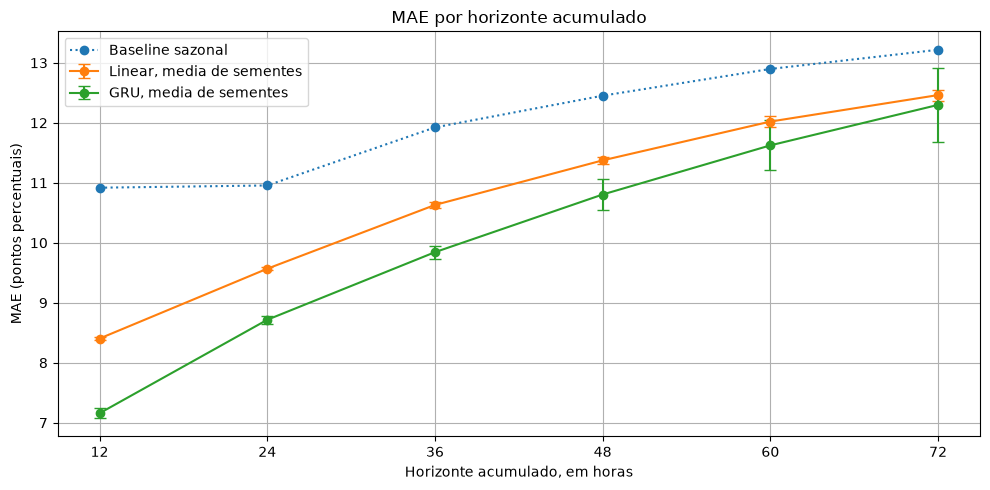

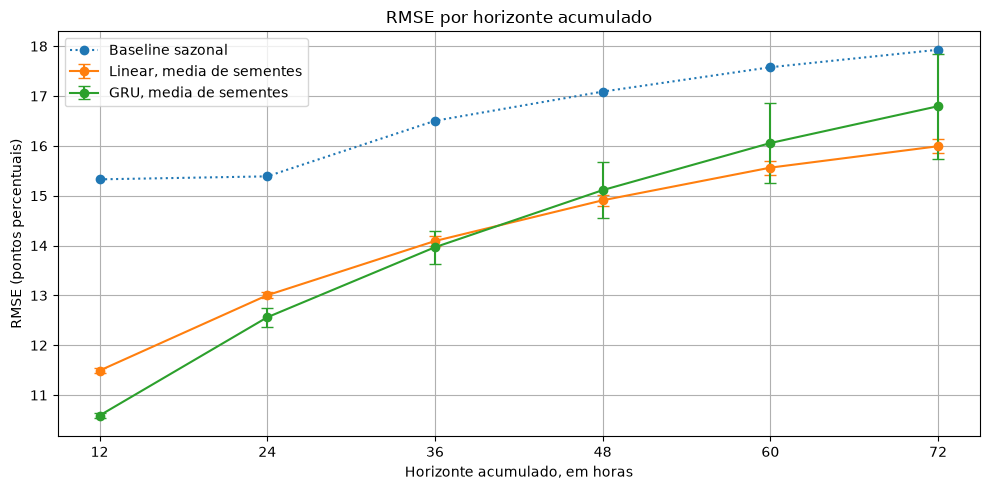

In [55]:
for metrica, titulo, arquivo in (
    ("mae", "MAE por horizonte acumulado", "mae_por_horizonte.png"),
    ("rmse", "RMSE por horizonte acumulado", "rmse_por_horizonte.png"),
):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Baseline
    grupo_base = resumo_final.loc[resumo_final["modelo"] == "Baseline sazonal"]
    ax.plot(
        grupo_base["horizonte"],
        grupo_base[f"{metrica}_media"],
        marker="o",
        linestyle=":",
        label="Baseline sazonal",
    )

    for nome_modelo in ("Linear", "GRU"):
        grupo = resumo_final.loc[resumo_final["modelo"] == nome_modelo]
        ax.errorbar(
            grupo["horizonte"],
            grupo[f"{metrica}_media"],
            yerr=grupo[f"{metrica}_dp"],
            marker="o",
            capsize=4,
            label=f"{nome_modelo}, media de sementes",
        )

    ax.set_xlabel("Horizonte acumulado, em horas")
    ax.set_ylabel(f"{metrica.upper()} ({UNIDADE_ERRO})")
    ax.set_title(titulo)
    ax.set_xticks(HORIZONTES)
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    fig.savefig(PASTA_SAIDAS / arquivo, dpi=150)
    plt.show()


In [56]:
def media_mae_por_origem(lista_resultados, horizonte):
    matriz = np.vstack([
        resultado[horizonte]["mae_por_origem"]
        for resultado in lista_resultados
    ])
    return matriz.mean(axis=0)

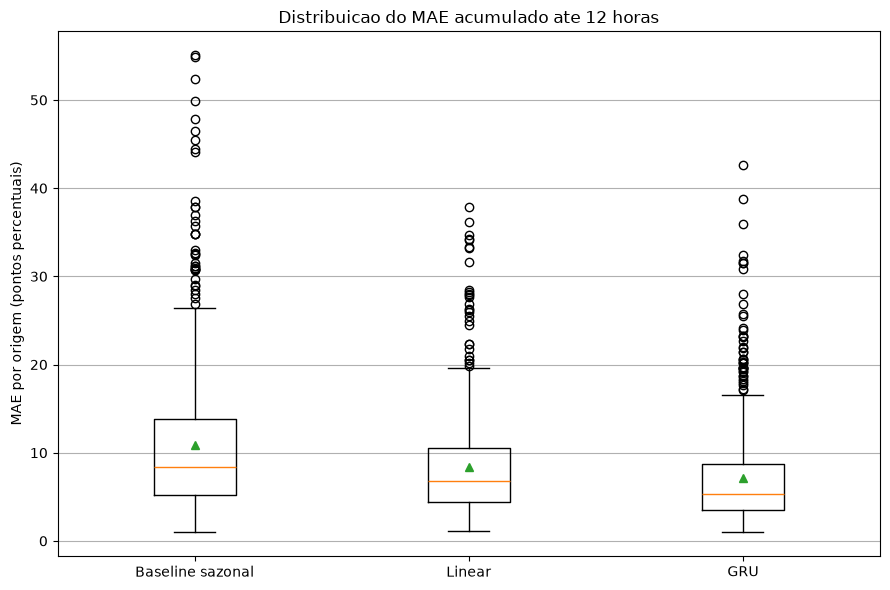

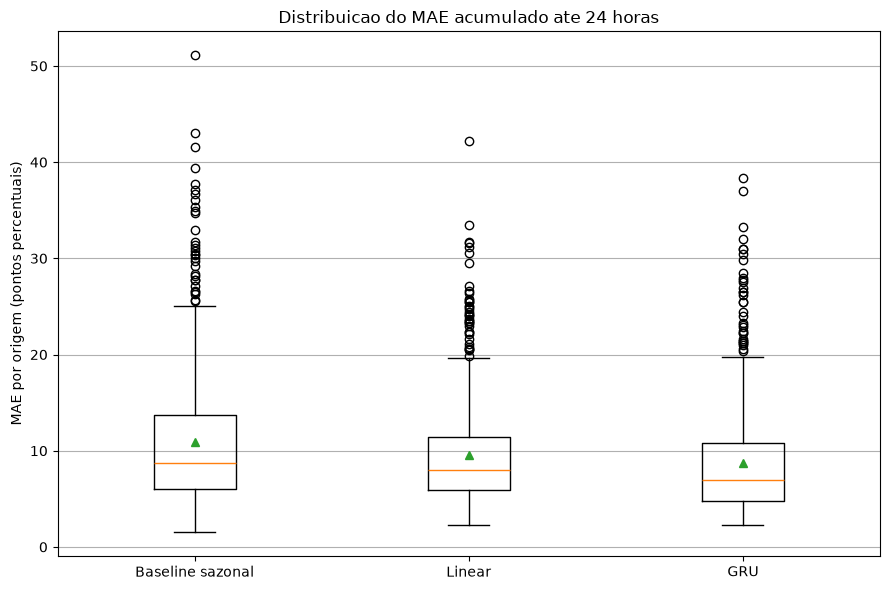

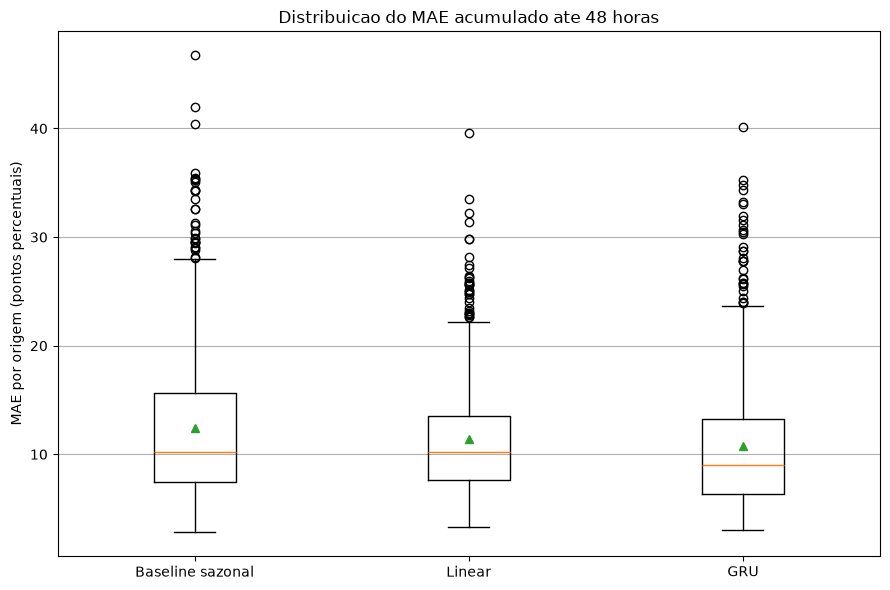

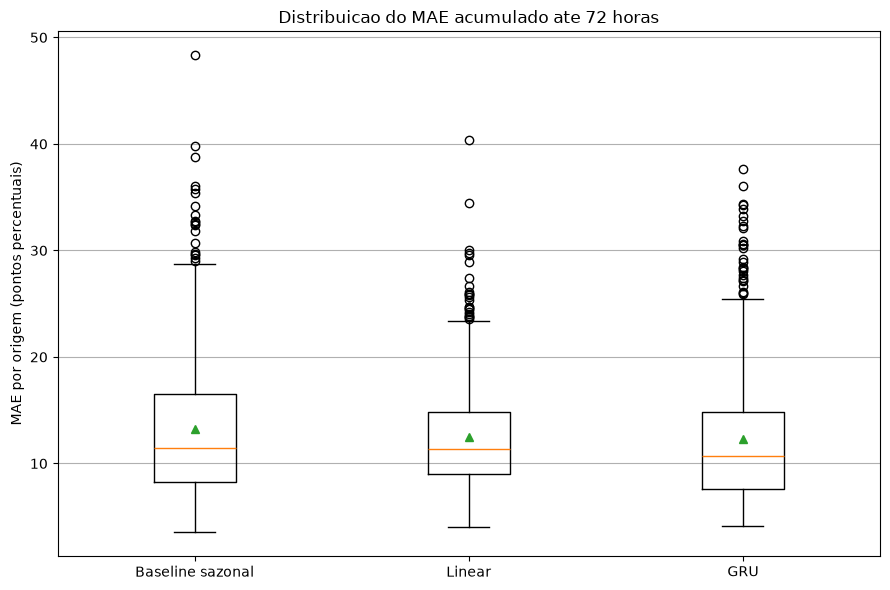

In [57]:
for horizonte in (12, 24, 48, 72):
    mae_baseline = np.asarray(
        resultados_baseline_teste[horizonte]["mae_por_origem"], dtype=float
    )
    mae_linear = media_mae_por_origem(
        resultados_modelos_teste["Linear"], horizonte
    )
    mae_gru = media_mae_por_origem(
        resultados_modelos_teste["GRU"], horizonte
    )

    assert len(mae_baseline) == len(mae_linear) == len(mae_gru)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.boxplot(
        [mae_baseline, mae_linear, mae_gru],
        tick_labels=["Baseline sazonal", "Linear", "GRU"],
        showmeans=True,
    )
    ax.set_ylabel(f"MAE por origem ({UNIDADE_ERRO})")
    ax.set_title(f"Distribuicao do MAE acumulado ate {horizonte} horas")
    ax.grid(True, axis="y")
    fig.tight_layout()
    fig.savefig(PASTA_SAIDAS / f"boxplot_mae_{horizonte}h.png", dpi=150)
    plt.show()


## 7.4. Trajetória comparativa de 72 horas

### 7.4.1. Definindo variáveis de tempo e valores de origem

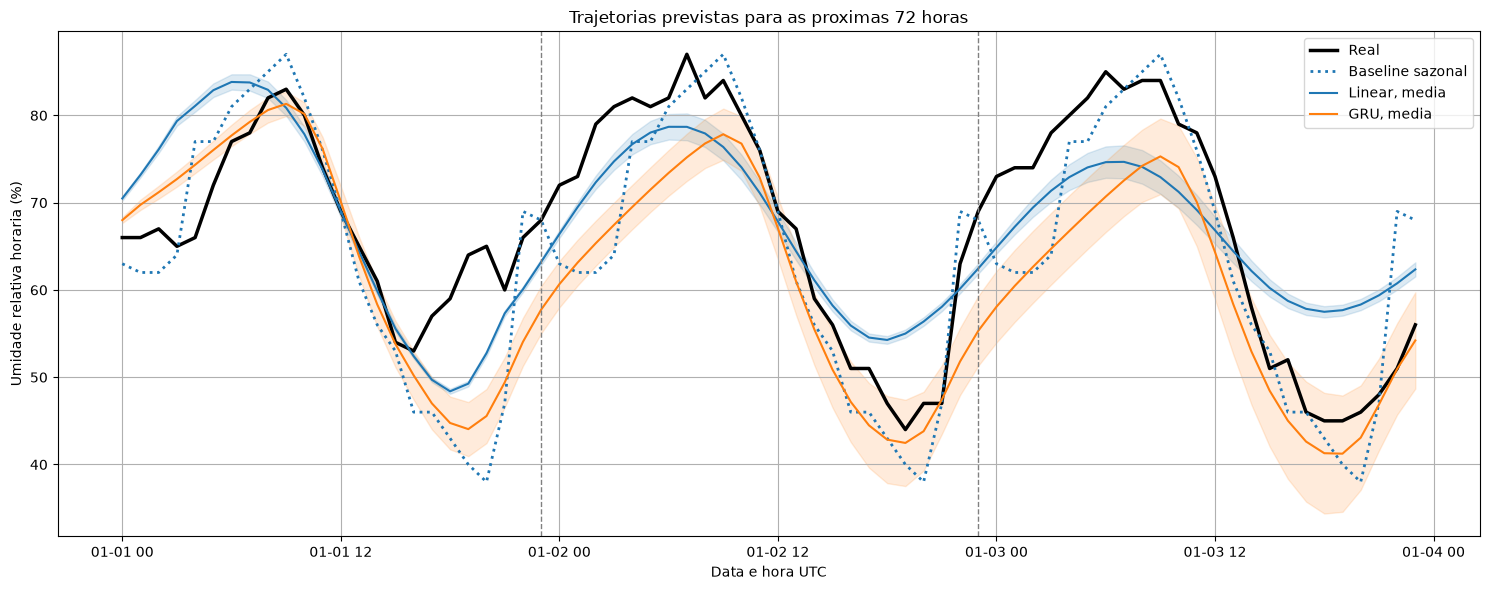

In [ ]:
# Trajetoria de 72 horas na primeira origem válida do teste.
origem_grafico = int(origens_teste[0])
horizonte_grafico = 72
datas_origem = datas_serie[origem_grafico:origem_grafico + horizonte_grafico]
real_origem = serie_original[origem_grafico:origem_grafico + horizonte_grafico]
pred_baseline_origem = previsao_sazonal(
    serie_original[:origem_grafico], horizonte_grafico, 24
)

previsoes_trajetoria = {}
for nome_modelo in ("Linear", "GRU"):
    matriz = []
    for modelo in modelos_treinados[nome_modelo]:
        pred_norm = previsao_recursiva(
            modelo,
            serie_normalizada[:origem_grafico],
            TAU,
            horizonte_grafico,
        )
        matriz.append(pred_norm * desvio_treino + media_treino)
    matriz = np.vstack(matriz)
    previsoes_trajetoria[nome_modelo] = {
        "media": matriz.mean(axis=0),
        "dp": matriz.std(axis=0, ddof=1),
    }

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(datas_origem, real_origem, color="black", linewidth=2.5, label="Real")
ax.plot(datas_origem, pred_baseline_origem, linestyle=":", linewidth=2, label="Baseline sazonal")
for nome_modelo, cor in (("Linear", "tab:blue"), ("GRU", "tab:orange")):
    media = previsoes_trajetoria[nome_modelo]["media"]
    dp = previsoes_trajetoria[nome_modelo]["dp"]
    ax.plot(datas_origem, media, color=cor, label=f"{nome_modelo}, media")
    ax.fill_between(datas_origem, media - dp, media + dp, color=cor, alpha=0.15)
ax.axvline(datas_origem[23], color="gray", linestyle="--", linewidth=1)
ax.axvline(datas_origem[47], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Data e hora UTC")
ax.set_ylabel(ROTULO_ALVO)
ax.set_title("Trajetorias previstas para as proximas 72 horas")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig(PASTA_SAIDAS / "trajetoria_comparativa_72h.png", dpi=150)
plt.show()


# 8. Teste de hipótese entre Linear e GRU

### Hipóteses
$$
H_0: \text{não há diferença de desempenho entre os modelos}
$$
$$
H_1: \text{há diferença de desempenho entre os modelos}
$$

## 8.1. Reavaliação com passo de 72 horas

Como o horizonte máximo é 72 horas, use origens não sobrepostas:

In [59]:
origens_hipotese = listar_origens_validas(
    DATA_INICIO_TESTE,
    DATA_FIM_TESTE,
    horizonte=72,
    passo=PASSO_ORIGEM_HIPOTESE,
)

In [60]:
resultados_hipotese = {"Linear": [], "GRU": []}
for nome_modelo in ("Linear", "GRU"):
    for modelo in modelos_treinados[nome_modelo]:
        resultados_hipotese[nome_modelo].append(
            avaliar_modelo_em_origens(modelo, origens_hipotese, (72,))
        )

Matrizes sementes × origens:

In [61]:
maes_linear_matriz = np.vstack([
    resultado[72]["mae_por_origem"]
    for resultado in resultados_hipotese["Linear"]
])
maes_gru_matriz = np.vstack([
    resultado[72]["mae_por_origem"]
    for resultado in resultados_hipotese["GRU"]
])

Média das cinco sementes em cada origem:

In [63]:
mae_linear_por_origem = maes_linear_matriz.mean(axis=0)
mae_gru_por_origem = maes_gru_matriz.mean(axis=0)

### 8.1.1. Executar e interpretar os testes
Diferenças

In [64]:
diferencas_mae = mae_linear_por_origem - mae_gru_por_origem

print(
    f"MAE médio do Linear: "
    f"{mae_linear_por_origem.mean():.3f}"
)

print(
    f"MAE médio da GRU: "
    f"{mae_gru_por_origem.mean():.3f}"
)

print(
    f"Diferença média Linear - GRU: "
    f"{diferencas_mae.mean():.3f}"
)

print(
    f"Diferença mediana Linear - GRU: "
    f"{np.median(diferencas_mae):.3f}"
)

if len(diferencas_mae) < 3:
    raise ValueError("Poucas origens validas para o teste pareado.")

MAE médio do Linear: 12.549
MAE médio da GRU: 12.622
Diferença média Linear - GRU: -0.073
Diferença mediana Linear - GRU: -0.151


Interpretação:

- resultado negativo em Linear - GRU: o modelo Linear apresentou MAE menor;
- resultado positivo: a GRU apresentou MAE menor;
- resultado próximo de zero: os modelos tiveram desempenho semelhante.

Você pode automatizar:

In [65]:
if diferencas_mae.mean() < 0:
    print(
        "Em média, o modelo Linear apresentou "
        "menor MAE que a GRU."
    )
elif diferencas_mae.mean() > 0:
    print(
        "Em média, a GRU apresentou "
        "menor MAE que o modelo Linear."
    )
else:
    print(
        "Os modelos apresentaram o mesmo "
        "MAE médio."
    )

Em média, o modelo Linear apresentou menor MAE que a GRU.


## 8.2. Wilcoxon pareado
É uma alternativa mais robusta quando a normalidade das diferenças é questionável:

In [66]:
estatistica_w, p_w = wilcoxon(
    mae_linear_por_origem,
    mae_gru_por_origem,
    alternative="two-sided",
)

## 8.3. Teste t pareado
Pode ser utilizado se as diferenças entre os MAEs por origem forem aproximadamente normais:

In [67]:
estatistica_t, p_t = ttest_rel(mae_linear_por_origem, mae_gru_por_origem)

## 8.4. Shapiro-Wilk para verificar a normalidade dessas diferenças:

In [68]:
estatistica_s, p_s = shapiro(diferencas_mae)

Interpretação usual:

- p_shapiro < 0.05: há evidências contra a normalidade;
- p_shapiro >= 0.05: não há evidências suficientes para rejeitar a normalidade.

Além disso, visualize:

## 8.5. Resultados:

In [69]:
resumo_testes = pd.DataFrame([
    {
        "horizonte": 72,
        "n_pares": len(diferencas_mae),
        "mae_linear_medio": mae_linear_por_origem.mean(),
        "mae_gru_medio": mae_gru_por_origem.mean(),
        "diferenca_media_linear_menos_gru": diferencas_mae.mean(),
        "wilcoxon_estatistica": estatistica_w,
        "wilcoxon_p": p_w,
        "t_pareado_estatistica": estatistica_t,
        "t_pareado_p": p_t,
        "shapiro_estatistica": estatistica_s,
        "shapiro_p": p_s,
    }
])

In [70]:
print("\nTESTES PAREADOS, HORIZONTE DE 72 HORAS")
print(resumo_testes.to_string(index=False))
resumo_testes.to_csv(
    PASTA_SAIDAS / "testes_pareados_72h.csv",
    index=False,
    encoding="utf-8-sig",
)


TESTES PAREADOS, HORIZONTE DE 72 HORAS
 horizonte  n_pares  mae_linear_medio  mae_gru_medio  diferenca_media_linear_menos_gru  wilcoxon_estatistica  wilcoxon_p  t_pareado_estatistica  t_pareado_p  shapiro_estatistica  shapiro_p
        72       99         12.549332      12.622295                         -0.072964                2455.0    0.944348               -0.20218     0.840195             0.985718    0.36438


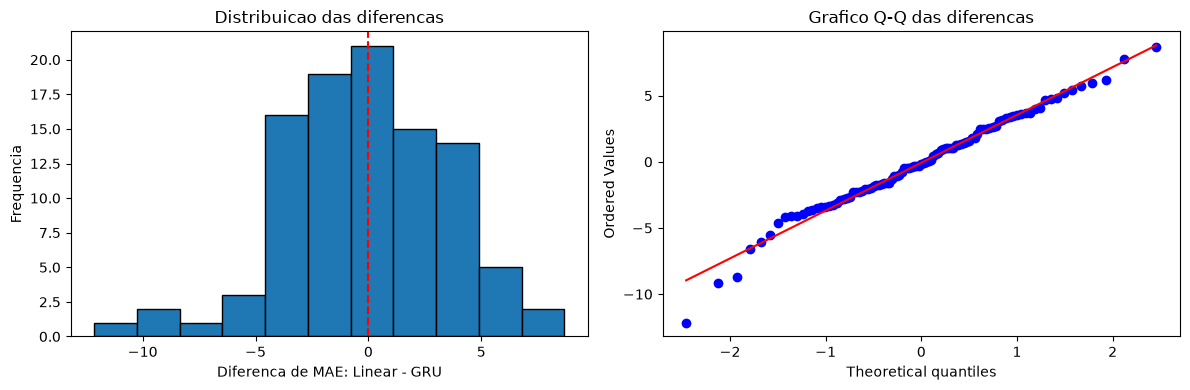

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(diferencas_mae, bins="auto", edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("Diferenca de MAE: Linear - GRU")
axes[0].set_ylabel("Frequencia")
axes[0].set_title("Distribuicao das diferencas")
stats.probplot(diferencas_mae, dist="norm", plot=axes[1])
axes[1].set_title("Grafico Q-Q das diferencas")
fig.tight_layout()
fig.savefig(PASTA_SAIDAS / "diagnostico_diferencas_mae_72h.png", dpi=150)
plt.show()

In [72]:
print("\nArquivos de resultado salvos em:", PASTA_SAIDAS.resolve())


Arquivos de resultado salvos em: C:\programas\univesp\pic-iv\resultados_relatorio_parcial


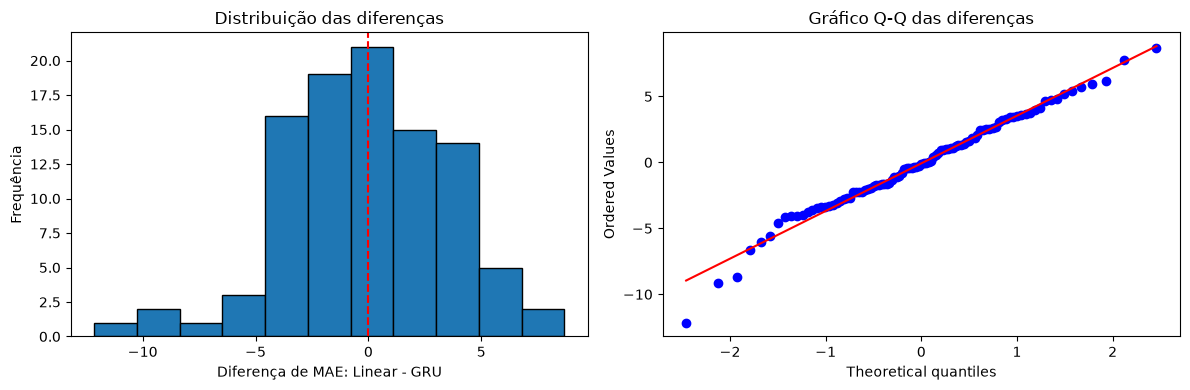

In [73]:
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    diferencas_mae,
    bins="auto",
    edgecolor="black"
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_xlabel("Diferença de MAE: Linear - GRU")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição das diferenças")

stats.probplot(
    diferencas_mae,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Gráfico Q-Q das diferenças")

plt.tight_layout()
plt.show()

Se houver poucos pares, valores extremos ou forte assimetria, eu priorizaria o Wilcoxon como análise mais conservadora.

# Z - Salvando os modelos

## 1. O que será salvo

Cada arquivo de checkpoint armazenará:

- tipo do modelo: `Linear` ou `GRU`;
- pesos treinados, por meio do `state_dict`;
- semente utilizada;
- `tau`, isto é, o tamanho da janela temporal;
- média e desvio-padrão calculados no conjunto de treinamento;
- hiperparâmetros da arquitetura;
- histórico das perdas de treinamento e validação;
- data e hora da execução.

Salvar a média, o desvio-padrão e o `tau` é essencial porque as previsões futuras precisam usar exatamente o mesmo pré-processamento empregado no treinamento.


## 2. Imports necessários


In [31]:
from pathlib import Path
from datetime import datetime
import gc
import random

import numpy as np
import pandas as pd
import torch
from torch import nn


## 3. Definição das arquiteturas

A classe da GRU e a função que cria o modelo linear precisam estar disponíveis antes de carregar os checkpoints.

In [32]:
class GRURegressor(nn.Module):
    def __init__(
        self,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Entrada original: (batch_size, tau)
        # Entrada da GRU: (batch_size, tau, 1)
        x = x.unsqueeze(-1)
        output, _ = self.gru(x)
        return self.output(output[:, -1, :])


def criar_modelo_linear(tau):
    return nn.Linear(tau, 1)


def criar_modelo_gru(
    hidden_size=64,
    num_layers=2,
    dropout=0.2
):
    return GRURegressor(
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    )


## 4. Criar pasta e identificação temporal da execução

Gere uma única identificação temporal para toda a rodada de treinamento. Assim, os modelos das diferentes sementes permanecem associados à mesma execução experimental.


In [33]:
# criar pasta se ela não existir
PASTA_MODELOS = Path("modelos_salvos")

if not PASTA_MODELOS.exists():
    PASTA_MODELOS.mkdir(
        parents=True,
        exist_ok=True
    )

In [34]:
data_hora_execucao = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

ID_EXECUCAO = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)

print("Identificação da execução:", ID_EXECUCAO)

Identificação da execução: 2026-09-23_06-44-46


## 5. Função para salvar um checkpoint

In [35]:
def salvar_checkpoint(
    modelo,
    nome_modelo,
    semente,
    tau,
    media_treino,
    desvio_treino,
    id_execucao,
    pasta_modelos,
    hiperparametros=None,
    historico=None,
    metadados_adicionais=None
):
    pasta_modelos = Path(pasta_modelos)
    pasta_modelos.mkdir(parents=True, exist_ok=True)

    nome_arquivo = (
        f"{nome_modelo.lower()}_"
        f"{COLUNA_ALVO.lower()}_"
        f"semente-{int(semente)}_"
        f"{id_execucao}.pth"
    )

    caminho = pasta_modelos / nome_arquivo

    checkpoint = {
        "versao_checkpoint": 1,
        "nome_modelo": str(nome_modelo),
        "semente": int(semente),
        "tau": int(tau),
        "media_treino": float(media_treino),
        "desvio_treino": float(desvio_treino),
        "id_execucao": str(id_execucao),
        "hiperparametros": hiperparametros or {},
        "historico": historico,
        "metadados_adicionais": metadados_adicionais or {},
        "model_state_dict": {
            nome: tensor.detach().cpu()
            for nome, tensor in modelo.state_dict().items()
        }
    }

    torch.save(checkpoint, caminho)

    print(f"Checkpoint salvo: {caminho}")
    return caminho


In [36]:
hiperparametros_linear = {
    "arquitetura": "nn.Linear",
    "entrada": TAU,
    "saida": 1,
    "lr": LR,
    "max_epocas": MAX_EPOCAS,
    "paciencia": PACIENCIA_LINEAR,
    "batch_size": BATCH_TREINO
}

hiperparametros_gru = {
    "arquitetura": "GRURegressor",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "saida": 1,
    "lr": LR,
    "max_epocas": MAX_EPOCAS,
    "paciencia": PACIENCIA_GRU,
    "batch_size": BATCH_TREINO
}

metadados_experimento = {
    "fim_treino": DATA_INICIO_VALIDACAO,
    "fim_validacao": DATA_INICIO_TESTE,
    "fim_teste": DATA_FIM_TESTE,
    "coluna_alvo": COLUNA_ALVO,
    "anos_treino": "2011 a 2013",
    "ano_validacao": 2024,
    "ano_teste": 2025
}


Para uma rastreabilidade ainda maior, registre no checkpoint:

- nome e hash do CSV;
- versão do Python;
- versão do PyTorch;
- versão do NumPy;
- dispositivo usado no treinamento;
- commit do Git correspondente ao código.

In [98]:
import hashlib
import platform


def calcular_sha256(caminho, tamanho_bloco=1024 * 1024):
    sha256 = hashlib.sha256()

    with open(caminho, "rb") as arquivo_aberto:
        while True:
            bloco = arquivo_aberto.read(tamanho_bloco)

            if not bloco:
                break

            sha256.update(bloco)

    return sha256.hexdigest()


metadados_experimento.update({
    "arquivo_csv": str(caminho),
    "sha256_csv": calcular_sha256(caminho),
    "python": platform.python_version(),
    "pytorch": torch.__version__,
    "numpy": np.__version__,
    "dispositivo_treinamento": str(device)
})

## 7. Salvar todos os modelos treinados

Este bloco pressupõe a existência das estruturas:

```python
modelos_treinados = {
    "Linear": [modelo_semente_10, ..., modelo_semente_50],
    "GRU": [modelo_semente_10, ..., modelo_semente_50]
}

historicos = {
    "Linear": [historico_10, ..., historico_50],
    "GRU": [historico_10, ..., historico_50]
}

SEMENTES = [10, 20, 30, 40, 50]


In [37]:
caminhos_modelos = {
    "Linear": [],
    "GRU": []
}

for nome_modelo in ["Linear", "GRU"]:
    for indice, modelo in enumerate(
        modelos_treinados[nome_modelo]
    ):
        semente = SEMENTES[indice]

        if nome_modelo == "Linear":
            hiperparametros = hiperparametros_linear
        else:
            hiperparametros = hiperparametros_gru

        caminho = salvar_checkpoint(
            modelo=modelo,
            nome_modelo=nome_modelo,
            semente=semente,
            tau=TAU,
            media_treino=media_treino,
            desvio_treino=desvio_treino,
            id_execucao=ID_EXECUCAO,
            pasta_modelos=PASTA_MODELOS,
            hiperparametros=hiperparametros,
            historico=historicos[nome_modelo][indice],
            metadados_adicionais=metadados_experimento
        )

        caminhos_modelos[nome_modelo].append(caminho)


Checkpoint salvo: modelos_salvos\linear_umidade_horaria_pct_semente-10_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\linear_umidade_horaria_pct_semente-20_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\linear_umidade_horaria_pct_semente-30_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\linear_umidade_horaria_pct_semente-40_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\linear_umidade_horaria_pct_semente-50_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\gru_umidade_horaria_pct_semente-10_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\gru_umidade_horaria_pct_semente-20_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\gru_umidade_horaria_pct_semente-30_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\gru_umidade_horaria_pct_semente-40_2026-09-23_06-44-46.pth
Checkpoint salvo: modelos_salvos\gru_umidade_horaria_pct_semente-50_2026-09-23_06-44-46.pth


## 8. Verificar se os arquivos foram gravados

In [38]:
for nome_modelo, caminhos in caminhos_modelos.items():
    print(f"\n{nome_modelo}:")

    for caminho in caminhos:
        assert caminho.exists(), (
            f"Arquivo não encontrado: {caminho}"
        )

        tamanho_mb = caminho.stat().st_size / 1024**2

        print(
            f"{caminho.name} | "
            f"{tamanho_mb:.3f} MB"
        )



Linear:
linear_umidade_horaria_pct_semente-10_2026-09-23_06-44-46.pth | 0.005 MB
linear_umidade_horaria_pct_semente-20_2026-09-23_06-44-46.pth | 0.005 MB
linear_umidade_horaria_pct_semente-30_2026-09-23_06-44-46.pth | 0.005 MB
linear_umidade_horaria_pct_semente-40_2026-09-23_06-44-46.pth | 0.004 MB
linear_umidade_horaria_pct_semente-50_2026-09-23_06-44-46.pth | 0.005 MB

GRU:
gru_umidade_horaria_pct_semente-10_2026-09-23_06-44-46.pth | 0.152 MB
gru_umidade_horaria_pct_semente-20_2026-09-23_06-44-46.pth | 0.152 MB
gru_umidade_horaria_pct_semente-30_2026-09-23_06-44-46.pth | 0.152 MB
gru_umidade_horaria_pct_semente-40_2026-09-23_06-44-46.pth | 0.151 MB
gru_umidade_horaria_pct_semente-50_2026-09-23_06-44-46.pth | 0.151 MB


## 9. Liberar a memória da GPU

In [1]:
# Move os modelos para a CPU antes de apagar as referências.
for nome_modelo in modelos_treinados:
    for modelo in modelos_treinados[nome_modelo]:
        modelo.to("cpu")

# Remove as referências mantidas pelo dicionário.
modelos_treinados.clear()
del modelos_treinados

# Remove possíveis referências temporárias.
for nome_variavel in [
    "modelo",
    "modelo_linear",
    "modelo_gru"
]:
    if nome_variavel in globals():
        del globals()[nome_variavel]


NameError: name 'modelos_treinados' is not defined

In [4]:
# Executa a coleta de lixo e libera o cache CUDA desocupado.
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(
        "Memória CUDA alocada: "
        f"{torch.cuda.memory_allocated() / 1024**2:.2f} MB"
    )

    print(
        "Memória CUDA reservada: "
        f"{torch.cuda.memory_reserved() / 1024**2:.2f} MB"
    )


Memória CUDA alocada: 0.00 MB
Memória CUDA reservada: 0.00 MB


## 10. Função para carregar um checkpoint

In [ ]:
def carregar_checkpoint(
    caminho,
    dispositivo=None
):
    caminho = Path(caminho)

    if not caminho.exists():
        raise FileNotFoundError(
            f"Checkpoint não encontrado: {caminho}"
        )

    if dispositivo is None:
        dispositivo = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
    else:
        dispositivo = torch.device(dispositivo)

    # map_location="cpu" evita ocupar a GPU durante a leitura.
    print(f"Carregando checkpoint: {caminho} para {dispositivo}")
    
    checkpoint = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )

    nome_modelo = checkpoint["nome_modelo"]
    tau_checkpoint = int(checkpoint["tau"])
    hiperparametros = checkpoint.get(
        "hiperparametros",
        {}
    )

    if nome_modelo == "Linear":
        modelo = criar_modelo_linear(
            tau=tau_checkpoint
        )

    elif nome_modelo == "GRU":
        modelo = criar_modelo_gru(
            hidden_size=hiperparametros.get(
                "hidden_size",
                64
            ),
            num_layers=hiperparametros.get(
                "num_layers",
                2
            ),
            dropout=hiperparametros.get(
                "dropout",
                0.2
            )
        )

    else:
        raise ValueError(
            f"Tipo de modelo desconhecido: {nome_modelo}"
        )

    modelo.load_state_dict(
        checkpoint["model_state_dict"]
    )

    modelo = modelo.to(dispositivo)
    modelo.eval()

    metadados = {
        chave: valor
        for chave, valor in checkpoint.items()
        if chave != "model_state_dict"
    }

    historico = checkpoint.get("historico", None)

    print(
        f"Modelo carregado: {nome_modelo} | "
        f"semente: {checkpoint['semente']} | "
        f"execução: {checkpoint['id_execucao']} | "
        f"dispositivo: {dispositivo}"
    )

    return modelo, metadados, historico

In [ ]:
# Definindo o dispositivo como CPU para evitar uso de GPU

device = torch.device("cpu")

In [ ]:
# Carregando um modelo Linear previamente treinado

caminho_linear = (
    PASTA_MODELOS
    / "linear_semente-10_2026-09-14_15-35-55.pth"
)

modelo_linear, meta_linear, historico_linear = carregar_checkpoint(
    caminho=caminho_linear,
    dispositivo="cpu"
)




In [ ]:
# Carregando um modelo GRU previamente treinado

caminho_gru = (
    PASTA_MODELOS
    / "gru_semente-10_2026-09-14_15-20-35.pth"
)

modelo_gru, meta_gru, historico_gru = carregar_checkpoint(
    caminho=caminho_gru,
    dispositivo="cpu"
)


In [74]:
print("Linear em modo de treino?", modelo_linear.training)
print("GRU em modo de treino?", modelo_gru.training)


NameError: name 'modelo_linear' is not defined

In [ ]:
def localizar_checkpoint_mais_recente(
    pasta,
    nome_modelo,
    semente=None
):
    pasta = Path(pasta)

    if semente is None:
        padrao = f"{nome_modelo.lower()}_semente-*_*.pth"
    else:
        padrao = (
            f"{nome_modelo.lower()}_"
            f"semente-{int(semente)}_*.pth"
        )

    arquivos = list(pasta.glob(padrao))

    if not arquivos:
        raise FileNotFoundError(
            f"Nenhum checkpoint corresponde a: {padrao}"
        )

    return max(
        arquivos,
        key=lambda arquivo: arquivo.stat().st_mtime
    )


In [ ]:
caminho_linear = localizar_checkpoint_mais_recente(
    pasta=PASTA_MODELOS,
    nome_modelo="Linear",
    semente=10
)

caminho_gru = localizar_checkpoint_mais_recente(
    pasta=PASTA_MODELOS,
    nome_modelo="GRU",
    semente=10
)

modelo_linear, meta_linear, historico_linear = carregar_checkpoint(
    caminho_linear,
    dispositivo="cpu"
)

modelo_gru, meta_gru, historico_gru = carregar_checkpoint(
    caminho_gru,
    dispositivo="cpu"
)


In [ ]:
tau_linear = int(meta_linear["tau"])
media_linear = float(meta_linear["media_treino"])
desvio_linear = float(meta_linear["desvio_treino"])

serie_normalizada_linear = (
    (serie - media_linear) / desvio_linear
).astype(np.float32)


In [ ]:
tau_gru = int(meta_gru["tau"])
media_gru = float(meta_gru["media_treino"])
desvio_gru = float(meta_gru["desvio_treino"])

serie_normalizada_gru = (
    (serie - media_gru) / desvio_gru
).astype(np.float32)


In [ ]:
assert tau_linear == tau_gru, (
    "Os modelos foram treinados com valores de tau diferentes."
)

assert np.isclose(media_linear, media_gru), (
    "As médias de treinamento não coincidem."
)

assert np.isclose(desvio_linear, desvio_gru), (
    "Os desvios-padrão de treinamento não coincidem."
)


Pronto para previsão e avaliação.